In [4]:
# 制御設計に用いるライブラリ

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import sympy as sp
import control
from control.matlab import *
sp.init_printing()

In [5]:
# グラフの線種を決めるジェネレータ関数
def linestyle_generator():
    linestyle = ['-', '--', '-.', ':']
    lineID = 0
    while True:
        yield linestyle[lineID]
        lineID = (lineID + 1) % len(linestyle)
        
# グラフを整える関数
def plot_set(fig_ax, *args):
    fig_ax.set_xlabel(args[0])
    fig_ax.set_ylabel(args[1])
    fig_ax.grid(ls=':')
    if len(args)==3:
        fig_ax.legend(loc=args[2])
        
# ボード線図を整える関数
def bodeplot_set(fig_ax, *args):
    # draw Gain
    fig_ax[0].grid(which="both", ls=':')
    fig_ax[0].set_ylabel('Gain [dB]')
    # draw Phase
    fig_ax[1].grid(which="both", ls=':')
    fig_ax[1].set_xlabel('Omega [rad/s]')
    fig_ax[1].set_ylabel('Phase [deg]')
    # 凡例の表示
    if len(args) > 0:
        fig_ax[0].legend(loc=args[0])
    if len(args) > 1:
        fig_ax[1].legend(loc=args[1])


In [6]:
# 垂直駆動アームのモデル
g = 9.81        # 重力加速度 [m/s^2]
l = 0.2         # アームの長さ [m]
M = 0.5         # アームの質量 [kg]
mu = 1.5e-2     # 粘性摩擦係数 [kg*m^2/s]
J = 1.0e-2      # 慣性モーメント [kg*m^2]

P = tf([0, 1], [J, mu, M*g*l])

# 目標角度
ref = 30    # [deg]

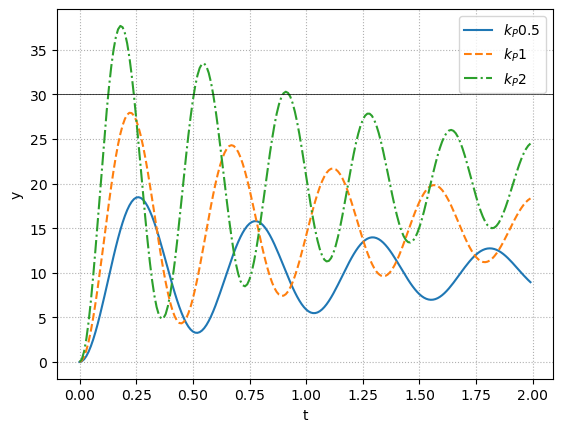

In [7]:
# P制御によるステップ応答
kp = (0.5, 1, 2)

LS = linestyle_generator()
fig, ax = plt.subplots()
for i in range(3):
    K = tf([0, kp[i]], [0, 1])
    Gyr = feedback(P*K, 1)
    y, t = step(Gyr, np.arange(0, 2, 0.01))
    
    pltargs = {'ls': next(LS), 'label': '$k_P$'+str(kp[i])}
    ax.plot(t, y*ref, **pltargs)
    
ax.axhline(ref, color="k", linewidth=0.5)
plot_set(ax, 't', 'y', 'best')

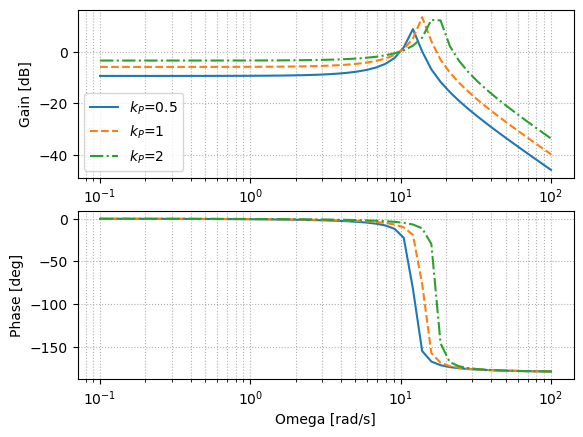

In [6]:
# P制御を用いた時のボード線図
LS = linestyle_generator()
fig, ax = plt.subplots(2, 1)

for i in range(len(kp)):
    K = tf([0, kp[i]], [0, 1])
    Gyr = feedback(P*K, 1)
    
    gain, phase, w = bode(Gyr, logspace(-1, 2), plot=False)
    
    pltargs = {'ls': next(LS), 'label': '$k_P$='+str(kp[i])}
    ax[0].semilogx(w, 20*np.log10(gain), **pltargs)
    ax[1].semilogx(w, phase*180/np.pi, **pltargs)

bodeplot_set(ax, 'lower left')

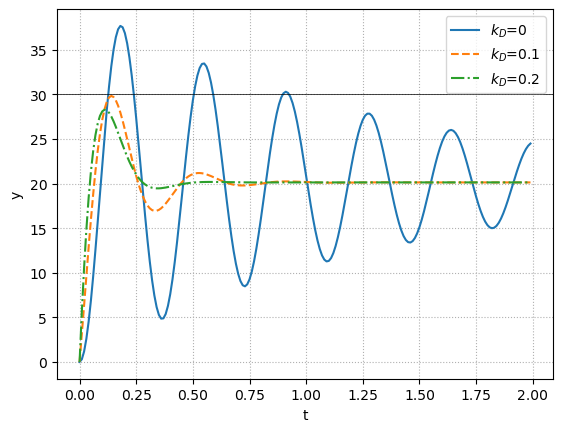

In [7]:
# PD制御によるステップ応答
kp = 2
kd = (0, 0.1, 0.2)

LS = linestyle_generator()
fig, ax = plt.subplots()
for i in range(3):
    K = tf([kd[i], kp], [0, 1])
    Gyr = feedback(P*K, 1)
    y, t = step(Gyr, np.arange(0, 2, 0.01))
    
    pltargs = {'ls': next(LS), 'label': '$k_D$='+str(kd[i])}
    ax.plot(t, y*ref, **pltargs)
    
ax.axhline(ref, color="k", linewidth=0.5)
plot_set(ax, 't', 'y', 'best')

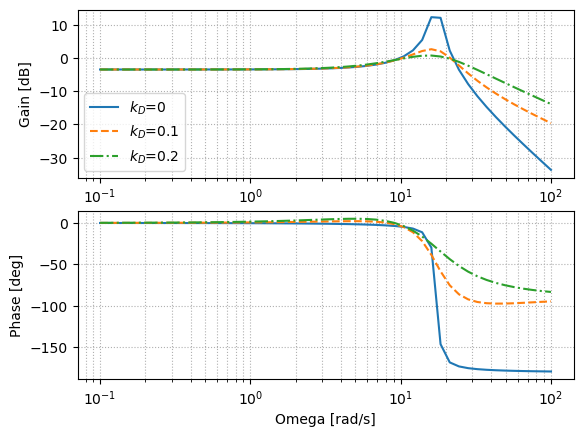

In [9]:
# PD制御を用いた時のボード線図
LS = linestyle_generator()
fig, ax = plt.subplots(2, 1)

for i in range(3):
    K = tf([kd[i], kp], [0, 1])
    Gyr = feedback(P*K, 1)
    
    gain, phase, w = bode(Gyr, logspace(-1, 2), plot=False)
    phase_deg = (phase*180/np.pi + 180) % 360 -180
    
    pltargs = {'ls': next(LS), 'label': '$k_D$='+str(kd[i])}
    ax[0].semilogx(w, 20*np.log10(gain), **pltargs)
    ax[1].semilogx(w, phase_deg, **pltargs)

bodeplot_set(ax, 'lower left')

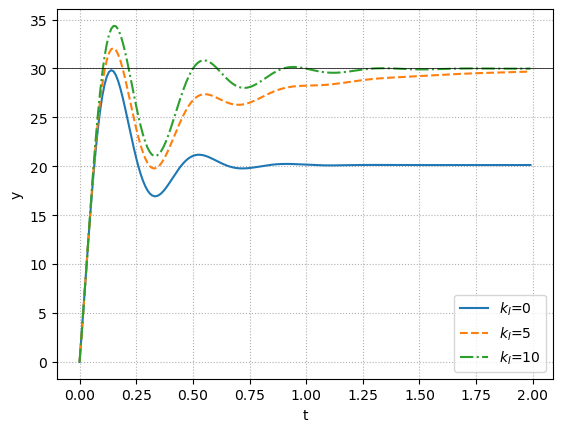

In [16]:
# PID制御によるステップ応答
kp = 2
kd = 0.1
ki = (0, 5, 10)

LS = linestyle_generator()
fig, ax = plt.subplots()
for i in range(3):
    K = tf([kd, kp, ki[i]], [1, 0])
    Gyr = feedback(P*K, 1)
    y, t = step(Gyr, np.arange(0, 2, 0.01))
    
    pltargs = {'ls': next(LS), 'label': '$k_I$='+str(ki[i])}
    ax.plot(t, y*ref, **pltargs)
    
ax.axhline(ref, color="k", linewidth=0.5)
plot_set(ax, 't', 'y', 'best')

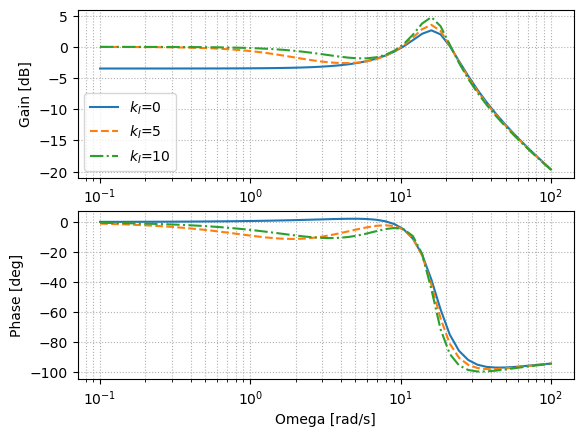

In [11]:
# PD制御を用いた時のボード線図
LS = linestyle_generator()
fig, ax = plt.subplots(2, 1)

for i in range(3):
    K = tf([kd, kp, ki[i]], [1, 0])
    Gyr = feedback(P*K, 1)
    
    gain, phase, w = bode(Gyr, logspace(-1, 2), plot=False)
    phase_deg = (phase*180/np.pi + 180) % 360 -180
    
    pltargs = {'ls': next(LS), 'label': '$k_I$='+str(ki[i])}
    ax[0].semilogx(w, 20*np.log10(gain), **pltargs)
    ax[1].semilogx(w, phase_deg, **pltargs)

bodeplot_set(ax, 'lower left')

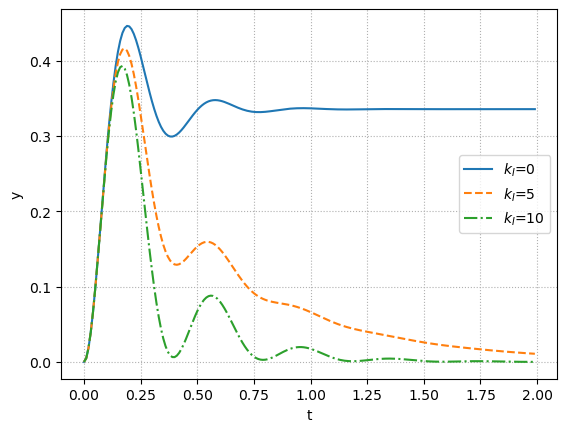

In [17]:
# PID制御の外乱抑制性能
LS = linestyle_generator()
fig, ax = plt.subplots()
for i in range(3):
    K = tf([kd, kp, ki[i]], [1, 0])
    Gyr = feedback(P, K)
    y, t = step(Gyr, np.arange(0, 2, 0.01))
    
    pltargs = {'ls': next(LS), 'label': '$k_I$='+str(ki[i])}
    ax.plot(t, y, **pltargs)
    
plot_set(ax, 't', 'y', 'center right')

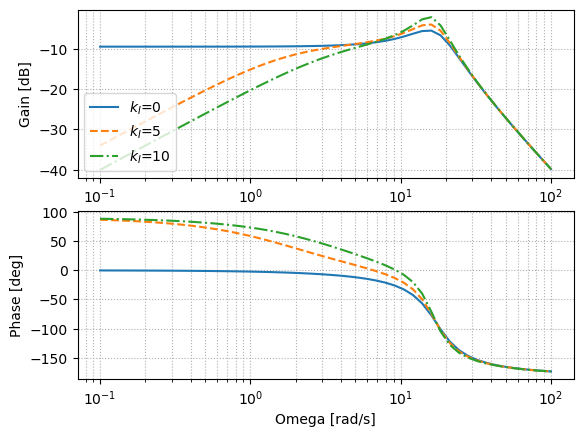

In [18]:
# PID制御を用いた時の外乱抑制(ボード線図)
LS = linestyle_generator()
fig, ax = plt.subplots(2, 1)

for i in range(3):
    K = tf([kd, kp, ki[i]], [1, 0])
    Gyr = feedback(P, K)
    
    gain, phase, w = bode(Gyr, logspace(-1, 2), plot=False)
    phase_deg = (phase*180/np.pi + 180) % 360 -180
    
    pltargs = {'ls': next(LS), 'label': '$k_I$='+str(ki[i])}
    ax[0].semilogx(w, 20*np.log10(gain), **pltargs)
    ax[1].semilogx(w, phase_deg, **pltargs)

bodeplot_set(ax, 'lower left')

PID制御では目標値がステップ状に変化すると制御入力に微分器で生成されるインパルス成分が含まれる。

そのため、実際には途中の経路の素子が飽和して意図した動作からずれることがある。

改良型のPID制御として、D成分に目標値を直接加えないPI-D制御とI-PD制御がある。

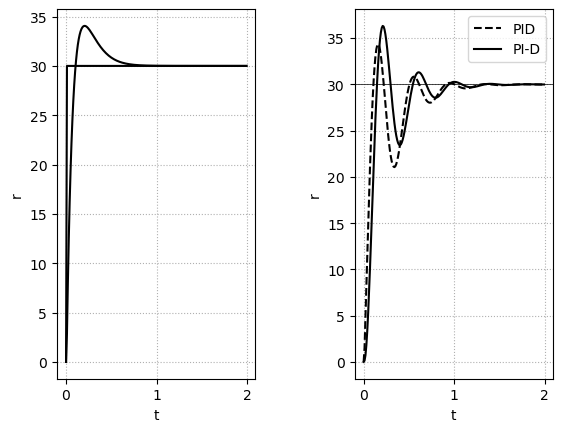

In [12]:
# PI-D制御（微分先行型PID制御）
# この型の制御では微分器への入力は出力として、目標入力を使わない。
# PID制御によるステップ応答
kp = 2
ki = 10
kd = 0.1

K1 = tf([kd, kp, ki], [1, 0])
K2 = tf([kp, ki], [kd, kp, ki])

Gyz = feedback(P*K1, 1)     # 目標入力から出力までの伝達関数

Td = np.arange(0, 2, 0.01)
r = 1*(Td>0)

z, t, _ = lsim(K2, r, Td, 0)

fig, ax = plt.subplots(1, 2)
plt.subplots_adjust(wspace=0.5)

# PID制御（入力がｒ）
y, _, _ = lsim(Gyz, r, Td, 0)
ax[0].plot(t, r*ref, color='k')
ax[1].plot(t, y*ref, ls='--', label='PID', color='k')
# PI-D制御
y, _, _ = lsim(Gyz, z, Td, 0)
ax[0].plot(t, z*ref, color='k')
ax[1].plot(t, y*ref, label='PI-D', color='k')
    
ax[1].axhline(ref, color="k", linewidth=0.5)
plot_set(ax[0], 't', 'r')
plot_set(ax[1], 't', 'r', 'best')

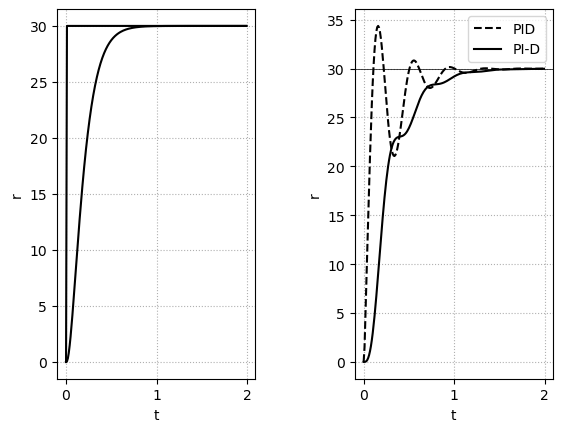

In [13]:
# I-PD制御（比例微分先行型PID制御）
# この型の制御では比例項と微分器への入力は出力として、目標入力を使わない。

kp = 2
ki = 10
kd = 0.1

K1 = tf([kd, kp, ki], [1, 0])
K2 = tf([0, ki], [kd, kp, ki])

Gyz = feedback(P*K1, 1)     # 目標入力から出力までの伝達関数

Td = np.arange(0, 2, 0.01)
r = 1*(Td>0)

z, t, _ = lsim(K2, r, Td, 0)

fig, ax = plt.subplots(1, 2)
plt.subplots_adjust(wspace=0.5)

# PID制御（入力がｒ）
y, _, _ = lsim(Gyz, r, Td, 0)
ax[0].plot(t, r*ref, color='k')
ax[1].plot(t, y*ref, ls='--', label='PID', color='k')
# PI-D制御
y, _, _ = lsim(Gyz, z, Td, 0)
ax[0].plot(t, z*ref, color='k')
ax[1].plot(t, y*ref, label='PI-D', color='k')
    
ax[1].axhline(ref, color="k", linewidth=0.5)
plot_set(ax[0], 't', 'r')
plot_set(ax[1], 't', 'r', 'best')

モデルマッチング法によるゲインチューニング

モデルマッチング法は、ある適切な規範モデルを与え、それに目標値から制御量までの伝達関数を一致させる。

規範モデルとしては２項係数標準形やバタワース標準形が利用される。

２次系の規範モデル

<div style="display: table; margin-left: 5;">

$M\left(s\right) = \dfrac{\omega_n^2}{s^2 + 2\zeta\omega_n + \omega_n^2}$

において、$\zeta = 1$ としたものが二項係数標準形、$\zeta = \dfrac{1}{\sqrt{2}}$ としたものがバタワース標準形である。



3次系の規範モデル

<div style="display: table; margin-left: 5;">

$M\left(s\right) = \dfrac{\omega_n^3}{s^3 + \alpha_2\omega_ns^2 + \alpha_1\omega_n^2s + \omega_n^3}$

において、($\alpha_1, \alpha_2$) = (3, 3) としたものが二項係数標準形、($\alpha_1, \alpha_2$) = (2, 2) としたものがバタワース標準形である。

($\alpha_1, \alpha_2$) = (2.15, 1.75) としたITAE最小標準形というものもある。

モデルマッチング法では、伝達関数 G(s) を求め、$\dfrac{1}{G(s)}$ のマクローリン展開と $\dfrac{1}{M(s)}$ のマクローリン展開を計算する。

その後、低次の項から一致するようにPIDゲインを決定する。

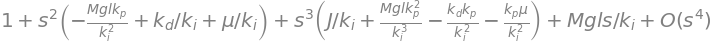

In [17]:
# 垂直駆動アームのモデル
g = 9.81        # 重力加速度 [m/s^2]
l = 0.2         # アームの長さ [m]
M = 0.5         # アームの質量 [kg]
mu = 1.5e-2     # 粘性摩擦係数 [kg*m^2/s]
J = 1.0e-2      # 慣性モーメント [kg*m^2]

# PI-D制御系の場合
s = sp.Symbol('s')
kp, kd, ki = sp.symbols('k_p k_d k_i')
Mgl, mu, J = sp.symbols('Mgl mu J')

G = (kp*s + ki) / (J*s**3 + (mu + kd)*s**2 + (Mgl + kp)*s + ki)
sp.series(1/G, s, 0, 4)


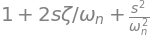

In [19]:
z, wn = sp.symbols('zeta omega_n')

MS = wn**2 / (s**2 + 2*z*wn*s + wn**2)
sp.series(1/MS, s, 0, 4)


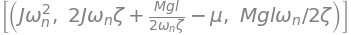

In [20]:
f1 = Mgl/ki - 2*z/wn
f2 = (mu + kd)/ki - Mgl*kp/(ki**2) - 1/(wn**2)
f3 = J/ki - kp*(mu + kd)/(ki**2) + Mgl*kp**2/(ki**3)

sp.solve([f1, f2, f3], [kp, kd, ki])

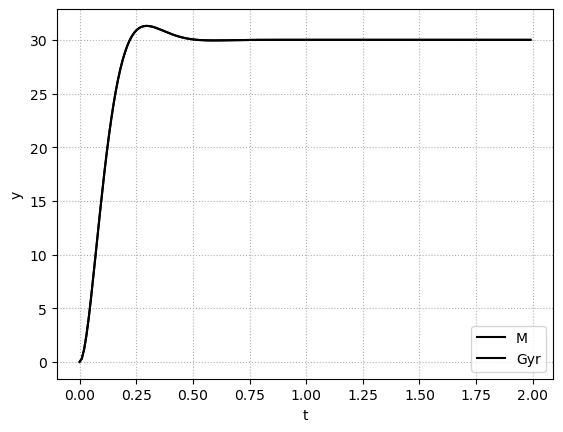

In [22]:
# 垂直駆動アームのモデル
g = 9.81        # 重力加速度 [m/s^2]
l = 0.2         # アームの長さ [m]
M = 0.5         # アームの質量 [kg]
mu = 1.5e-2     # 粘性摩擦係数 [kg*m^2/s]
J = 1.0e-2      # 慣性モーメント [kg*m^2]

omega_n = 15
zeta = 0.707

Msys = tf([0, omega_n**2], [1, 2*zeta*omega_n, omega_n**2])

kp = omega_n**2*J
ki = omega_n*M*g*l/(2*zeta)
kd = 2*zeta*omega_n*J + M*g*l/(2*zeta*omega_n) -mu
Gyr = tf([kp, ki], [J, mu + kd, M*g*l + kp, ki])

yM, tM = step(Msys, np.arange(0, 2, 0.01))
y, t = step(Gyr, np.arange(0, 2, 0.01))

fig, ax = plt.subplots()
ax.plot(tM, yM*ref, label='M', color='k')
ax.plot(t, y*ref, label='Gyr', color='k')
plot_set(ax, 't', 'y', 'best')